In [28]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


# function to scale the y-axis data between 0 and 1
def scale_y(data, scale=True):
    """
    Scales the y-axis data between 0 and 1.
    
    Parameters:
    data (array-like): The y-axis data to be scaled.
    
    Returns:
    array-like: Scaled y-axis data.
    """
    if not scale:
        return data
    
    return (data - np.min(data)) / (np.max(data) - np.min(data))



In [29]:
import glob as glob

files = glob.glob(f'pl-data-3/WS2-unknown-power100uw*.csv')
files


['pl-data-3/WS2-unknown-power100uw-10s (unknown) 2025-06-10 14_39_40.csv',
 'pl-data-3/WS2-unknown-power100uw-1s 2025-06-10 14_34_58.csv',
 'pl-data-3/WS2-unknown-power100uw-1s (unknown) 2025-06-10 14_38_33.csv',
 'pl-data-3/WS2-unknown-power100uw-20s (unknown) 2025-06-10 14_41_03.csv',
 'pl-data-3/WS2-unknown-power100uw-1s (unknown+WS2) 2025-06-10 14_44_15.csv']

In [30]:

scale = True

# plt.figure(figsize=(20,14))

# for file in files:
#     df = pd.read_csv(file, delimiter="\t")
    
#     plt.plot(df["Wavelength"], scale_y(df["Intensity"], scale), label=file)
    
    
# plt.grid(True)
# plt.legend(loc = "upper left")
# plt.yscale("log")


# scale = False

# plt.plot(unknown_mono["Wavelength"], scale_y(unknown_mono["Intensity"], scale))

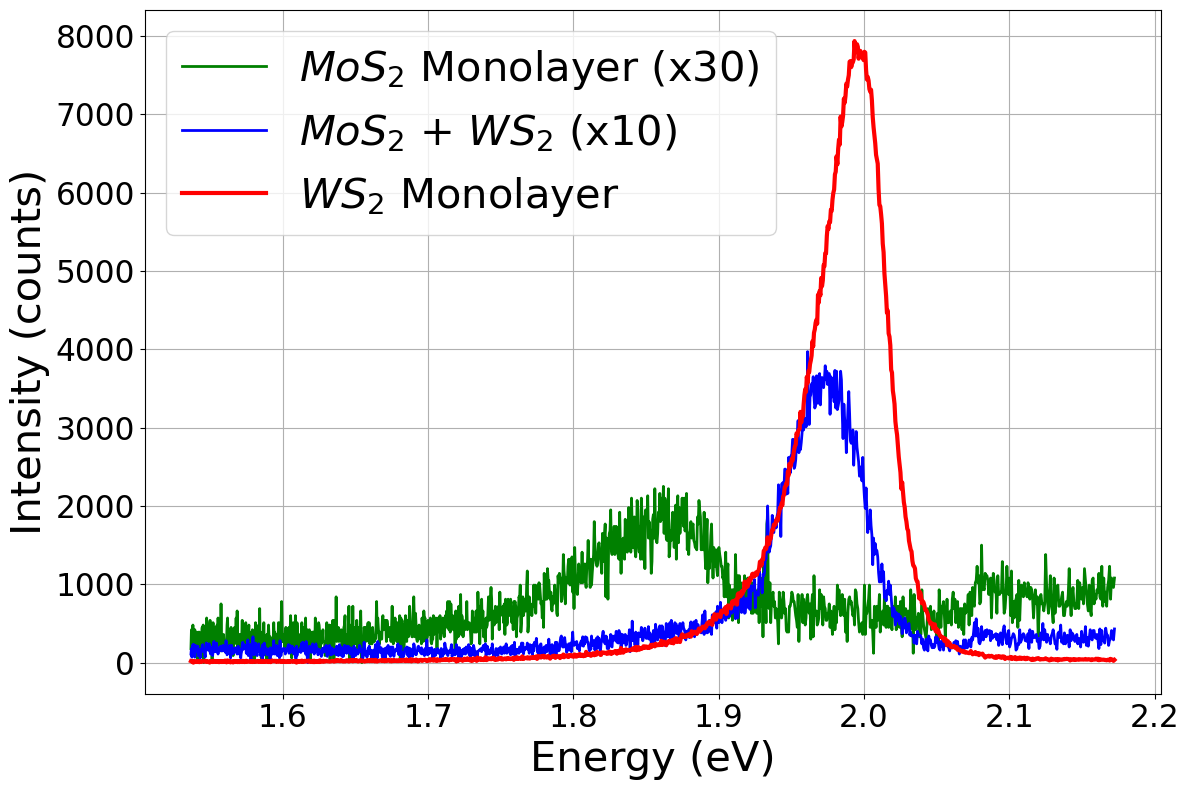

In [31]:
from os import remove
from turtle import color


ws2_mono = pd.read_csv('pl-data-3/WS2-unknown-power100uw-1s 2025-06-10 14_34_58.csv', delimiter="\t")
unknown_mono = pd.read_csv('pl-data-3/WS2-unknown-power100uw-1s (unknown) 2025-06-10 14_38_33.csv', delimiter="\t")
hetero = pd.read_csv('pl-data-3/WS2-unknown-power100uw-1s (unknown+WS2) 2025-06-10 14_44_15.csv', delimiter="\t")


def remove_background(df):
    df['Intensity'] = df['Intensity'] - df['Intensity'].min()
    return df

ws2_mono = remove_background(ws2_mono)
unknown_mono = remove_background(unknown_mono)
hetero = remove_background(hetero)

scale = False

fontsize = 30

factor  = 10
factor2 = 30


plt.figure(figsize=(12, 8))
plt.plot(unknown_mono['Wavelength'], scale_y(unknown_mono['Intensity'], scale)*factor2, 
         label=f'$MoS_2$ Monolayer (x{factor2})', linewidth=2, color = "green")
plt.plot(hetero['Wavelength'], scale_y(hetero['Intensity'], scale)*factor, 
         label=f'$MoS_2$ + $WS_2$ (x{factor})', linewidth=2, color = "blue")
plt.plot(ws2_mono['Wavelength'], scale_y(ws2_mono['Intensity'], scale), 
         label=f'$WS_2$ Monolayer ', linewidth=3, color="red")

plt.xlabel('Energy (eV)', fontsize=fontsize)
plt.ylabel('Intensity (counts)', fontsize=fontsize)
# plt.title('PL Spectra for the Unknown Monolayer', fontsize=fontsize)


plt.grid(True)

plt.legend(loc="upper left", fontsize=fontsize)
plt.xticks(fontsize=fontsize*0.75)
plt.yticks(fontsize=fontsize*0.75)

plt.tight_layout()  # Optional: makes sure labels don't get cut off


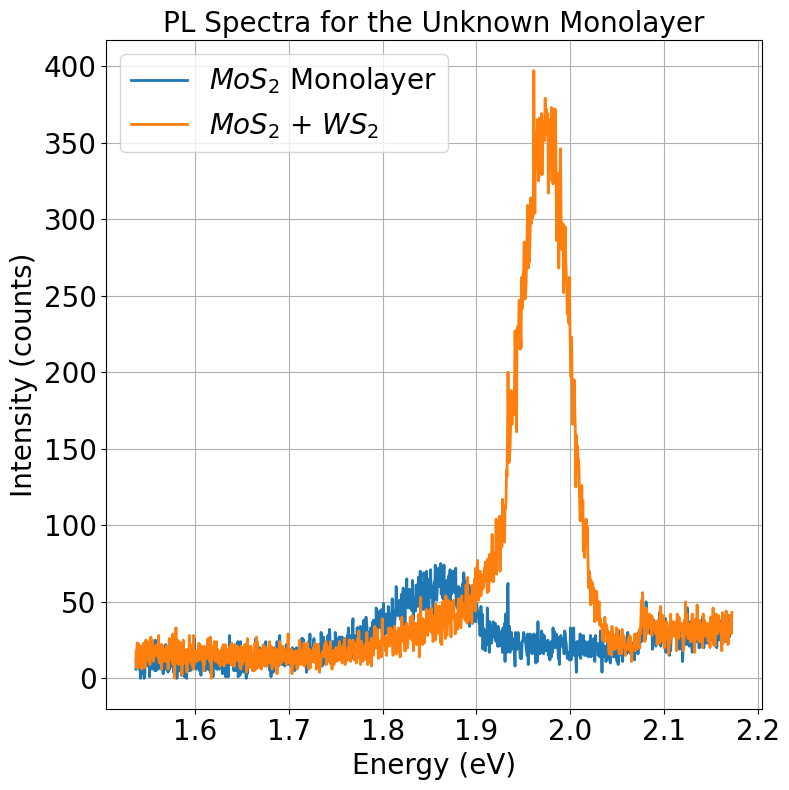

In [32]:
plt.figure(figsize=(8, 8))
plt.plot(unknown_mono['Wavelength'], scale_y(unknown_mono['Intensity'], scale), 
         label='$MoS_2$ Monolayer', linewidth=2)
plt.plot(hetero['Wavelength'], scale_y(hetero['Intensity'], scale), 
         label='$MoS_2$ + $WS_2$', linewidth=2)

plt.xlabel('Energy (eV)', fontsize=20)
plt.ylabel('Intensity (counts)', fontsize=20)
plt.title('PL Spectra for the Unknown Monolayer', fontsize=20)

plt.grid(True)
plt.legend(loc='upper left', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
